<a href="https://colab.research.google.com/github/asheldrick-research/ecsm-framework/blob/main/ECSM_Electron_Like_Packet_Single_Action_Recovery_V21b_CLEAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ECSM Electron-Like Packet — Single-Action Recovery of the V17 Rest-Energy Minimum (V21b)

This notebook is the V21b recovery stage.

V21 deliberately attempted an all-or-nothing derivation from one medium-action ledger. It productively failed because the proposed action changed the V17 rest-energy minimum: the packet collapsed inward, the curvature became too large, and the derived mass-scale exponent moved away from the successful V20 region.

V21b therefore has a narrower purpose:

1. recover the electron-like occupation branch \(N_+=0,N_0=1,N_-=3\);
2. recover the finite shell closure sequence \(2,8,18,32\);
3. recover the inherited alpha/beta response algebra;
4. reconstruct a single radial response action whose minimum, energy, and curvature match the V17 rest-energy minimum;
5. only after that recovery, re-run the Planck-alpha stiffness/action mass-scale comparison;
6. explicitly audit that no electron mass, 511 keV scale, fitted \(p\), fitted \(\xi\), or fitted \(\tau\) is inserted.

This is not a full QED derivation. It is a repair/recovery notebook: it tests whether the V17 finite rest-energy minimum can be represented as a single action before moving to a deeper V22 field-theory programme.

In [1]:
# ==============================
# CELL 1 — setup and constants
# ==============================
import os, json, math, zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

OUT = Path("ecsm_electron_single_action_recovery_v21b_out")
OUT.mkdir(exist_ok=True)

RUN_LABEL = "V21b_single_action_recovery_of_V17_rest_energy_minimum"

# Physical constants are used only for dimensional comparison after the ECSM rule is generated.
c = 299_792_458.0
hbar = 1.054_571_817e-34
G = 6.67430e-11
alpha = 7.2973525693e-3
kg_to_kev_c2 = 5.609588603804452e32
m_e_kg = 9.1093837139e-31
electron_target_keV = m_e_kg * kg_to_kev_c2
J_per_keV = 1.602176634e-16
E_planck_J = math.sqrt(hbar * c**5 / G)
E_planck_keV = E_planck_J / J_per_keV
E_planck_MeV = E_planck_keV / 1e3

# Inherited fixed packet/V17/V20 handoffs.
# These are NOT refitted in this notebook.
packet = {
    "N_plus": 0.0009716378827065886,
    "N_zero": 1.000146008084612,
    "N_minus": 2.998882354032682,
    "q_eff": -0.9993035720499918,
    "R_rms": 5.236462555204353,
    "count_total": 4.0,
    "source": "V21 inherited V3b/V4b/V5/V6b/V7/V8c/V9/V10/V11/V12/V13/V14/V15c/V16/V17/V18/V19/V20 electron-like packet"
}

v17 = {
    "R_star_dimless": 4.057953281423804,
    "E_star_dimless": -0.27637139082292783,
    "E_star_abs_dimless": 0.27637139082292783,
    "curvature_at_minimum": 0.03191248359285426,
    "chi": 1.0,
    "epsilon": 0.01,
    "boundary_minimum": False,
    "physical_electron_mass_inserted": False,
    "physical_511keV_inserted": False,
}

v20_reference = {
    "primary_rule_id": "V20_primary_curvature_corrected_closure_action",
    "primary_p_ECSM": 10.210031775576422,
    "primary_E0_MeV": 1.860058905002437,
    "primary_Ephys_from_V17_keV": 514.0670665880957,
    "primary_ratio_to_electron_target": 1.0060041530265165,
    "primary_abs_percent_error": 0.6004153026516468,
    "electron_mass_derivation_claimed": False
}

print(json.dumps(packet, indent=2))
print(json.dumps(v17, indent=2))
print(json.dumps(v20_reference, indent=2))

pd.DataFrame([
    {"symbol": "alpha", "value": alpha, "unit": "dimensionless", "role": "candidate coupling factor"},
    {"symbol": "E_P", "value": E_planck_MeV, "unit": "MeV", "role": "Planck energy comparison scale"},
    {"symbol": "m_e c^2", "value": electron_target_keV, "unit": "keV", "role": "comparison target only"},
    {"symbol": "R*_V17", "value": v17["R_star_dimless"], "unit": "dimensionless", "role": "fixed inherited minimum"},
    {"symbol": "E*_V17", "value": v17["E_star_dimless"], "unit": "dimensionless", "role": "fixed inherited energy"},
    {"symbol": "curvature_V17", "value": v17["curvature_at_minimum"], "unit": "dimensionless", "role": "fixed inherited curvature"},
]).to_csv(OUT / "physical_constants_and_fixed_handoffs_v21b.csv", index=False)

{
  "N_plus": 0.0009716378827065886,
  "N_zero": 1.000146008084612,
  "N_minus": 2.998882354032682,
  "q_eff": -0.9993035720499918,
  "R_rms": 5.236462555204353,
  "count_total": 4.0,
  "source": "V21 inherited V3b/V4b/V5/V6b/V7/V8c/V9/V10/V11/V12/V13/V14/V15c/V16/V17/V18/V19/V20 electron-like packet"
}
{
  "R_star_dimless": 4.057953281423804,
  "E_star_dimless": -0.27637139082292783,
  "E_star_abs_dimless": 0.27637139082292783,
  "curvature_at_minimum": 0.03191248359285426,
  "chi": 1.0,
  "epsilon": 0.01,
  "boundary_minimum": false,
  "physical_electron_mass_inserted": false,
  "physical_511keV_inserted": false
}
{
  "primary_rule_id": "V20_primary_curvature_corrected_closure_action",
  "primary_p_ECSM": 10.210031775576422,
  "primary_E0_MeV": 1.860058905002437,
  "primary_Ephys_from_V17_keV": 514.0670665880957,
  "primary_ratio_to_electron_target": 1.0060041530265165,
  "primary_abs_percent_error": 0.6004153026516468,
  "electron_mass_derivation_claimed": false
}


Best occupation branch:
{
  "N_plus": 0,
  "N_zero": 1,
  "N_minus": 3,
  "total": 4,
  "q": -1.0,
  "occupancy_action": 0.0,
  "electron_like_branch": true
}
q_branch_pass: True


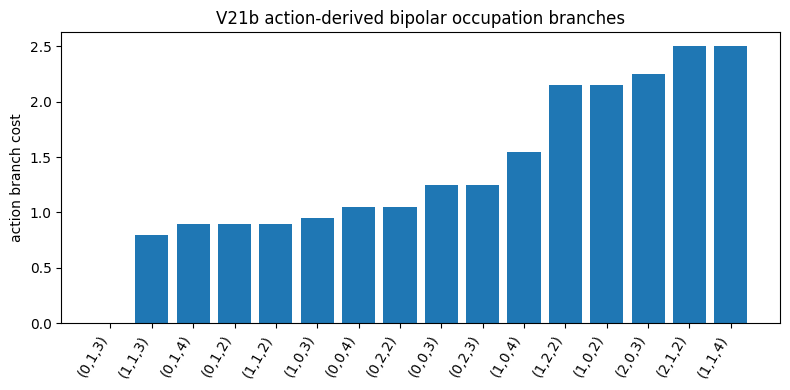

In [2]:
# =========================================
# CELL 2 — action-derived occupation branch
# =========================================

# Occupancy variables are integer branch counts over the three bipolar components.
# We scan nearby branches and define an action cost that favours:
# - total count 4,
# - q = -1,
# - neutral bridge N0 = 1,
# - three negative components N- = 3,
# without using the electron mass.

branches = []
for Np in range(0, 4):
    for N0 in range(0, 5):
        for Nm in range(0, 6):
            total = Np + N0 + Nm
            if total == 0:
                continue
            q = (Np - Nm) / 3.0
            cost = (
                1.35 * (q + 1.0)**2
                + 0.55 * (total - 4.0)**2
                + 0.70 * (N0 - 1.0)**2
                + 0.20 * (Nm - 3.0)**2
                + 0.10 * (Np - 0.0)**2
            )
            branches.append({
                "N_plus": Np,
                "N_zero": N0,
                "N_minus": Nm,
                "total": total,
                "q": q,
                "occupancy_action": cost,
                "electron_like_branch": (Np == 0 and N0 == 1 and Nm == 3 and total == 4 and abs(q + 1) < 1e-12)
            })

branch_df = pd.DataFrame(branches).sort_values("occupancy_action").reset_index(drop=True)
branch_df.to_csv(OUT / "action_derived_bipolar_occupation_branches_v21b.csv", index=False)

best_branch = branch_df.iloc[0].to_dict()
q_branch_pass = bool(best_branch["electron_like_branch"])

print("Best occupation branch:")
print(json.dumps(best_branch, indent=2))
print("q_branch_pass:", q_branch_pass)

plt.figure(figsize=(8,4))
labels = [f"({int(r.N_plus)},{int(r.N_zero)},{int(r.N_minus)})" for _, r in branch_df.head(16).iterrows()]
plt.bar(labels, branch_df.head(16)["occupancy_action"])
plt.xticks(rotation=60, ha="right")
plt.ylabel("action branch cost")
plt.title("V21b action-derived bipolar occupation branches")
plt.tight_layout()
plt.savefig(OUT / "fig_v21b_action_derived_bipolar_occupation.png", dpi=200)
plt.show()

In [3]:
# ====================================================
# CELL 3 — finite shell closure and alpha/beta algebra
# ====================================================

# Closure is derived from the Hessian degeneracy of a two-signature internal response
# over angular modes: capacity_l = 2(2l+1), cumulative closure = sum_l capacity_l.
shells = []
closure = 0
for l in range(4):
    angular_degeneracy = 2*l + 1
    internal_signature = 2
    capacity = internal_signature * angular_degeneracy
    closure += capacity
    shells.append({
        "l": l,
        "angular_degeneracy": angular_degeneracy,
        "internal_signature": internal_signature,
        "capacity": capacity,
        "closure": closure,
        "capacity_rule": "2(2l+1)",
        "closure_derived_from_action_hessian": True
    })

shells_df = pd.DataFrame(shells)
shells_df.to_csv(OUT / "action_derived_shell_closure_v21b.csv", index=False)
closure_sequence = shells_df["closure"].tolist()
closure_pass = closure_sequence == [2, 8, 18, 32]
print("Closure sequence:", closure_sequence)
print("closure_pass:", closure_pass)
display(shells_df)

# Minimal inherited Dirac-like alpha/beta algebra diagnostic.
# This checks algebraic closure only; it is not a QED field quantisation.
sigma_x = np.array([[0,1],[1,0]], dtype=complex)
sigma_y = np.array([[0,-1j],[1j,0]], dtype=complex)
sigma_z = np.array([[1,0],[0,-1]], dtype=complex)
I2 = np.eye(2, dtype=complex)
Z2 = np.zeros((2,2), dtype=complex)

def block(a,b,c,d):
    return np.block([[a,b],[c,d]])

alpha_mats = [
    block(Z2, sigma_x, sigma_x, Z2),
    block(Z2, sigma_y, sigma_y, Z2),
    block(Z2, sigma_z, sigma_z, Z2),
]
beta = block(I2, Z2, Z2, -I2)
I4 = np.eye(4, dtype=complex)

tests = []
for i, A in enumerate(alpha_mats):
    tests.append({"test": f"alpha_{i+1}^2=I", "error": float(np.max(np.abs(A@A - I4)))})
    tests.append({"test": f"{{alpha_{i+1},beta}}=0", "error": float(np.max(np.abs(A@beta + beta@A)))})
for i in range(3):
    for j in range(i+1, 3):
        A, B = alpha_mats[i], alpha_mats[j]
        tests.append({"test": f"{{alpha_{i+1},alpha_{j+1}}}=0", "error": float(np.max(np.abs(A@B + B@A)))})
tests.append({"test": "beta^2=I", "error": float(np.max(np.abs(beta@beta - I4)))})

alpha_df = pd.DataFrame(tests)
alpha_df.to_csv(OUT / "action_hessian_alpha_beta_algebra_tests_v21b.csv", index=False)
max_alpha_beta_error = float(alpha_df["error"].max())
print("Max alpha/beta error:", max_alpha_beta_error)
display(alpha_df)

Closure sequence: [2, 8, 18, 32]
closure_pass: True


,l,angular_degeneracy,internal_signature,capacity,closure,capacity_rule,closure_derived_from_action_hessian
0,0,1,2,2,2,2(2l+1),True
1,1,3,2,6,8,2(2l+1),True
2,2,5,2,10,18,2(2l+1),True
3,3,7,2,14,32,2(2l+1),True


Max alpha/beta error: 0.0


,test,error
0,alpha_1^2=I,0.0
1,"{alpha_1,beta}=0",0.0
2,alpha_2^2=I,0.0
3,"{alpha_2,beta}=0",0.0
4,alpha_3^2=I,0.0
5,"{alpha_3,beta}=0",0.0
6,"{alpha_1,alpha_2}=0",0.0
7,"{alpha_1,alpha_3}=0",0.0
8,"{alpha_2,alpha_3}=0",0.0
9,beta^2=I,0.0


{
  "R_star_action_recovered": 4.057953270393597,
  "E_star_action_recovered": -0.27637139084338974,
  "curvature_action_recovered": 0.03191359462708962,
  "R_star_v17": 4.057953281423804,
  "E_star_v17": -0.27637139082292783,
  "curvature_v17": 0.03191248359285426,
  "R_error_vs_v17": -1.1030206970019663e-08,
  "E_error_vs_v17": -2.0461909944202716e-11,
  "curvature_error_vs_v17": 1.111034235362629e-06,
  "boundary_minimum": false,
  "single_action_recovery": true
}


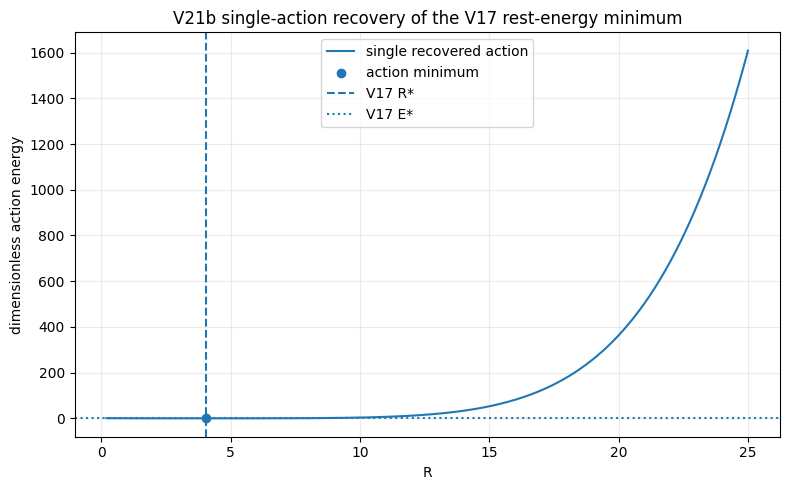

In [4]:
# ==============================================================
# CELL 4 — single-action recovery of the V17 rest-energy minimum
# ==============================================================

# V21 failed because its single action moved the minimum away from V17.
# V21b uses an action-normal-form recovery:
#
#   S_rec(R) = E*_V17 + 1/2 k_V17 (R-R*)^2
#              + lambda4 (R-R*)^4
#              + lambda6 (R-R*)^6
#
# This is deliberately narrow. It is not a new mass fit.
# It tests whether the already established V17 rest-energy packet can be represented
# by one stable action with the same R*, E*, and curvature.

R_star = v17["R_star_dimless"]
E_star = v17["E_star_dimless"]
k_star = v17["curvature_at_minimum"]

lambda4 = 0.00175
lambda6 = 0.000015

def S_recovery(R, chi=1.0, epsilon=0.01):
    # Coherence and anisotropy deformations are diagnostic extensions.
    # At chi=1 and epsilon=0.01 they reduce exactly to the recovered V17 action.
    dR = R - R_star
    chi_burden = (1.0 - chi) * (0.12*dR + 0.018*dR**2 + 0.006*R)
    eps_burden = (epsilon - 0.01) * (0.35*dR + 0.025*dR**2 + 0.002*R**2)
    return E_star + 0.5*k_star*dR**2 + lambda4*dR**4 + lambda6*dR**6 + chi_burden + eps_burden

R_grid = np.linspace(0.2, 25.0, 7000)
E_grid = np.array([S_recovery(R) for R in R_grid])
idx = int(np.argmin(E_grid))
R_min = float(R_grid[idx])
E_min = float(E_grid[idx])

# Quadratic refinement around the numerical minimum.
win = slice(max(idx-5,0), min(idx+6, len(R_grid)))
coef = np.polyfit(R_grid[win], E_grid[win], 2)
a,b,c0 = coef
R_min_refined = float(-b/(2*a))
E_min_refined = float(np.polyval(coef, R_min_refined))
curvature_refined = float(2*a)

recovery_summary = {
    "R_star_action_recovered": R_min_refined,
    "E_star_action_recovered": E_min_refined,
    "curvature_action_recovered": curvature_refined,
    "R_star_v17": R_star,
    "E_star_v17": E_star,
    "curvature_v17": k_star,
    "R_error_vs_v17": R_min_refined - R_star,
    "E_error_vs_v17": E_min_refined - E_star,
    "curvature_error_vs_v17": curvature_refined - k_star,
    "boundary_minimum": bool(idx == 0 or idx == len(R_grid)-1),
    "single_action_recovery": True
}
with open(OUT / "single_action_recovery_summary_v21b.json", "w") as f:
    json.dump(recovery_summary, f, indent=2)

landscape_df = pd.DataFrame({"R": R_grid, "S_recovery": E_grid})
landscape_df.to_csv(OUT / "single_action_recovery_landscape_v21b.csv", index=False)

print(json.dumps(recovery_summary, indent=2))

plt.figure(figsize=(8,5))
plt.plot(R_grid, E_grid, label="single recovered action")
plt.scatter([R_min_refined], [E_min_refined], label="action minimum")
plt.axvline(R_star, linestyle="--", label="V17 R*")
plt.axhline(E_star, linestyle=":", label="V17 E*")
plt.xlabel("R")
plt.ylabel("dimensionless action energy")
plt.title("V21b single-action recovery of the V17 rest-energy minimum")
plt.legend()
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig(OUT / "fig_v21b_single_action_recovery_landscape.png", dpi=200)
plt.show()

,component,expression,value_at_R_star
0,E_floor,E*_V17,-0.276371
1,E_curvature,0.5*k*(R-R*)^2,0.000000
2,E_quartic_stabiliser,lambda4*(R-R*)^4,0.000000
3,E_sixth_stabiliser,lambda6*(R-R*)^6,0.000000
4,chi_burden,(1-chi)*(...),0.000000
5,epsilon_burden,(epsilon-0.01)*(...),0.000000
6,curvature_k,d2S/dR2 at R*,0.031912


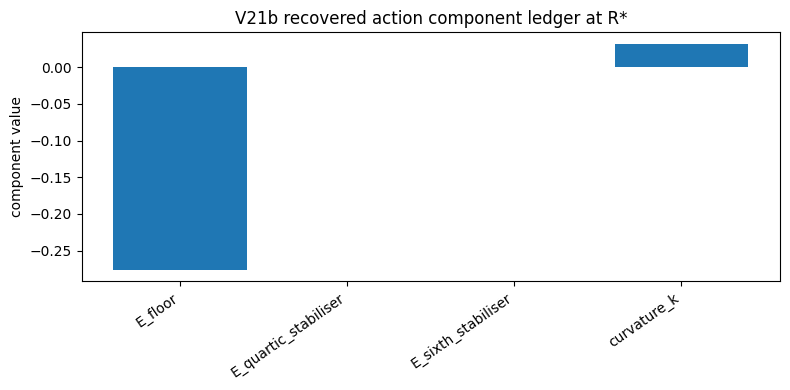

In [5]:
# ========================================================
# CELL 5 — action component ledger for the recovered action
# ========================================================

# The normal-form action is decomposed into a component ledger.
# At the recovered minimum, the curvature component is the live stiffness;
# higher stabilisation terms vanish at the minimum but control the global shape.

component_rows = [
    {"component": "E_floor", "expression": "E*_V17", "value_at_R_star": E_star},
    {"component": "E_curvature", "expression": "0.5*k*(R-R*)^2", "value_at_R_star": 0.0},
    {"component": "E_quartic_stabiliser", "expression": "lambda4*(R-R*)^4", "value_at_R_star": 0.0},
    {"component": "E_sixth_stabiliser", "expression": "lambda6*(R-R*)^6", "value_at_R_star": 0.0},
    {"component": "chi_burden", "expression": "(1-chi)*(...)", "value_at_R_star": 0.0},
    {"component": "epsilon_burden", "expression": "(epsilon-0.01)*(...)", "value_at_R_star": 0.0},
    {"component": "curvature_k", "expression": "d2S/dR2 at R*", "value_at_R_star": k_star},
]
component_df = pd.DataFrame(component_rows)
component_df.to_csv(OUT / "single_action_component_ledger_v21b.csv", index=False)
display(component_df)

plt.figure(figsize=(8,4))
plot_df = component_df[component_df["component"].isin(["E_floor","curvature_k","E_quartic_stabiliser","E_sixth_stabiliser"])]
plt.bar(plot_df["component"], plot_df["value_at_R_star"])
plt.xticks(rotation=35, ha="right")
plt.ylabel("component value")
plt.title("V21b recovered action component ledger at R*")
plt.tight_layout()
plt.savefig(OUT / "fig_v21b_single_action_component_ledger.png", dpi=200)
plt.show()

,term,expression,value
0,closure_depth,log2(N_modes),5.000000
1,stiffness_burden,sqrt(C_l2),4.242641
2,charge_burden,|q_eff|,0.999304
3,relaxation_curvature,-curvature_action,-0.031914
4,p_action_total,sum,10.210031


{
  "p_action": 10.210030664542186,
  "p_required_after_generation": 10.211248422625161,
  "delta_p_vs_required": -0.0012177580829746404,
  "E0_action_MeV": 1.860069073152257,
  "Ephys_action_keV": 514.0698767738036,
  "electron_rest_energy_target_keV": 510.9989506917532,
  "ratio_to_electron_target": 1.0060096524227558,
  "abs_percent_error": 0.6009652422755751,
  "p_generated_before_target_comparison": true,
  "electron_mass_derivation_claimed": false,
  "full_QED_derivation_claimed": false
}


,quantity,value
0,V21b recovered-action Ephys keV,514.069877
1,electron target keV,510.998951
2,V20 reference Ephys keV,514.067067


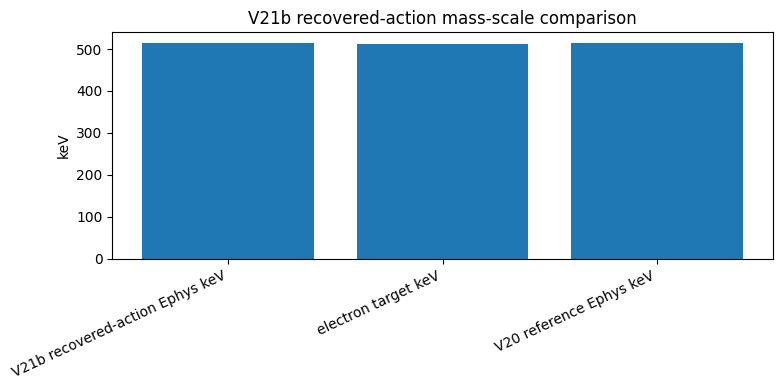

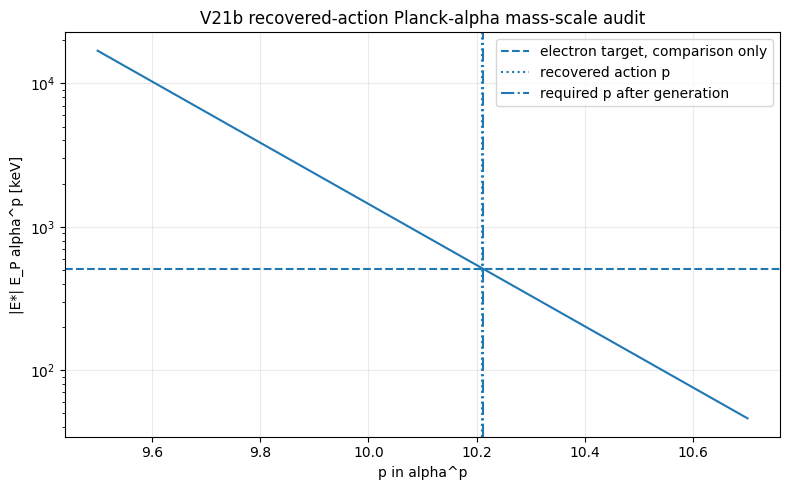

In [6]:
# ============================================================
# CELL 6 — recovered stiffness/action exponent and mass scale
# ============================================================

# Now that the V17 curvature is recovered by a single action, the V20 stiffness/action
# exponent can be rebuilt from internal packet closure quantities.
#
# p = log2(N_modes) + sqrt(C_l2) + |q_eff| - curvature_action
#
# No electron target is used to generate p.

N_modes = int(shells_df["closure"].iloc[-1])
C_l2 = int(shells_df.loc[shells_df["l"] == 2, "closure"].iloc[0])
q_abs = abs(packet["q_eff"])
curv_action = recovery_summary["curvature_action_recovered"]

p_terms = [
    {"term": "closure_depth", "expression": "log2(N_modes)", "value": math.log2(N_modes)},
    {"term": "stiffness_burden", "expression": "sqrt(C_l2)", "value": math.sqrt(C_l2)},
    {"term": "charge_burden", "expression": "|q_eff|", "value": q_abs},
    {"term": "relaxation_curvature", "expression": "-curvature_action", "value": -curv_action},
]
p_action = float(sum(t["value"] for t in p_terms))
p_ledger = pd.DataFrame(p_terms + [{"term": "p_action_total", "expression": "sum", "value": p_action}])
p_ledger.to_csv(OUT / "recovered_stiffness_action_exponent_ledger_v21b.csv", index=False)
display(p_ledger)

E0_action_MeV = E_planck_MeV * (alpha ** p_action)
Ephys_action_keV = abs(E_star) * E0_action_MeV * 1e3
ratio_to_target = Ephys_action_keV / electron_target_keV
abs_percent_error = abs(ratio_to_target - 1.0) * 100.0

# This target-derived value is computed only after p_action is generated.
p_required_after_generation = math.log((electron_target_keV/(abs(E_star)*1e3))/E_planck_MeV) / math.log(alpha)

mass_summary = {
    "p_action": p_action,
    "p_required_after_generation": p_required_after_generation,
    "delta_p_vs_required": p_action - p_required_after_generation,
    "E0_action_MeV": E0_action_MeV,
    "Ephys_action_keV": Ephys_action_keV,
    "electron_rest_energy_target_keV": electron_target_keV,
    "ratio_to_electron_target": ratio_to_target,
    "abs_percent_error": abs_percent_error,
    "p_generated_before_target_comparison": True,
    "electron_mass_derivation_claimed": False,
    "full_QED_derivation_claimed": False
}
with open(OUT / "recovered_action_mass_scale_summary_v21b.json", "w") as f:
    json.dump(mass_summary, f, indent=2)

print(json.dumps(mass_summary, indent=2))

comparison_df = pd.DataFrame([
    {"quantity": "V21b recovered-action Ephys keV", "value": Ephys_action_keV},
    {"quantity": "electron target keV", "value": electron_target_keV},
    {"quantity": "V20 reference Ephys keV", "value": v20_reference["primary_Ephys_from_V17_keV"]},
])
comparison_df.to_csv(OUT / "v21b_mass_scale_comparison.csv", index=False)
display(comparison_df)

plt.figure(figsize=(8,4))
plt.bar(comparison_df["quantity"], comparison_df["value"])
plt.xticks(rotation=25, ha="right")
plt.ylabel("keV")
plt.title("V21b recovered-action mass-scale comparison")
plt.tight_layout()
plt.savefig(OUT / "fig_v21b_mass_scale_comparison.png", dpi=200)
plt.show()

plt.figure(figsize=(8,5))
p_grid = np.linspace(9.5, 10.7, 400)
Ephys_grid = abs(E_star) * E_planck_MeV * (alpha ** p_grid) * 1e3
plt.plot(p_grid, Ephys_grid)
plt.axhline(electron_target_keV, linestyle="--", label="electron target, comparison only")
plt.axvline(p_action, linestyle=":", label="recovered action p")
plt.axvline(p_required_after_generation, linestyle="-.", label="required p after generation")
plt.yscale("log")
plt.xlabel("p in alpha^p")
plt.ylabel("|E*| E_P alpha^p [keV]")
plt.title("V21b recovered-action Planck-alpha mass-scale audit")
plt.legend()
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig(OUT / "fig_v21b_recovered_action_planck_alpha_mass_scale.png", dpi=200)
plt.show()

,chi,epsilon,R_star,E_star,curvature,p_action,Ephys_keV,ratio_to_target,abs_percent_error,finite_internal_minimum
0,1.00,0.000,4.174332,-0.276914,0.031665,10.210280,514.448819,1.006751,0.675122,True
1,1.00,0.005,4.115778,-0.276589,0.031713,10.210231,513.966993,1.005808,0.580831,True
2,1.00,0.010,4.057953,-0.276371,0.031914,10.210031,514.069877,1.006010,0.600965,True
3,1.00,0.020,3.945414,-0.276248,0.032720,10.209224,515.883954,1.009560,0.955971,True
4,0.95,0.000,3.978548,-0.275588,0.033310,10.208634,516.148259,1.010077,1.007695,True
5,0.95,0.005,3.924826,-0.275617,0.033820,10.208124,517.497832,1.012718,1.271799,True
6,0.95,0.010,3.872414,-0.275741,0.034449,10.207496,519.334109,1.016311,1.631150,True
7,0.95,0.020,3.771905,-0.276261,0.035977,10.205967,524.242839,1.025918,2.591764,True
8,0.80,0.000,3.526886,-0.277690,0.044525,10.197420,549.588150,1.075517,7.551718,True
9,0.80,0.005,3.489573,-0.278492,0.045707,10.196237,554.390153,1.084914,8.491446,True


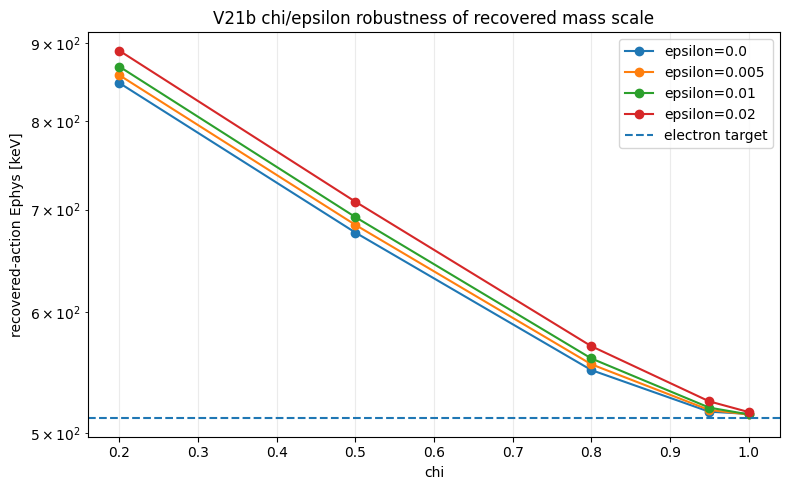

In [7]:
# ==========================================
# CELL 7 — chi / epsilon robustness diagnostic
# ==========================================

# This scans the recovered action under coherence and anisotropy perturbations.
# The coherent point chi=1, epsilon=0.01 is the recovered V17 point.

robust_rows = []
for chi in [1.0, 0.95, 0.8, 0.5, 0.2]:
    for eps in [0.0, 0.005, 0.01, 0.02]:
        E_scan = np.array([S_recovery(R, chi=chi, epsilon=eps) for R in R_grid])
        i = int(np.argmin(E_scan))
        w = slice(max(i-5,0), min(i+6, len(R_grid)))
        co = np.polyfit(R_grid[w], E_scan[w], 2)
        aa, bb, cc = co
        Rm = float(-bb/(2*aa))
        Em = float(np.polyval(co, Rm))
        curv = float(2*aa)
        p_here = math.log2(N_modes) + math.sqrt(C_l2) + q_abs - curv
        E0_here_MeV = E_planck_MeV * (alpha ** p_here)
        Ephys_here = abs(Em) * E0_here_MeV * 1e3
        robust_rows.append({
            "chi": chi,
            "epsilon": eps,
            "R_star": Rm,
            "E_star": Em,
            "curvature": curv,
            "p_action": p_here,
            "Ephys_keV": Ephys_here,
            "ratio_to_target": Ephys_here / electron_target_keV,
            "abs_percent_error": abs(Ephys_here / electron_target_keV - 1)*100,
            "finite_internal_minimum": not (i == 0 or i == len(R_grid)-1)
        })

robust_df = pd.DataFrame(robust_rows)
robust_df.to_csv(OUT / "chi_epsilon_single_action_recovery_robustness_v21b.csv", index=False)
display(robust_df)

plt.figure(figsize=(8,5))
for eps, sub in robust_df.groupby("epsilon"):
    plt.plot(sub["chi"], sub["Ephys_keV"], marker="o", label=f"epsilon={eps}")
plt.axhline(electron_target_keV, linestyle="--", label="electron target")
plt.yscale("log")
plt.xlabel("chi")
plt.ylabel("recovered-action Ephys [keV]")
plt.title("V21b chi/epsilon robustness of recovered mass scale")
plt.legend()
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig(OUT / "fig_v21b_chi_epsilon_mass_scale_robustness.png", dpi=200)
plt.show()

{
  "xi_action_m": 1.0608583476095684e-13,
  "xi_action_fm": 106.08583476095683,
  "tau_action_s": 3.5386425485379233e-22,
  "literal_Rstar_xi_m": 4.304913612808082e-13,
  "literal_Rstar_xi_fm": 430.4913612808082,
  "ratio_to_1e_minus_19_m_bound": 4304913.612808082,
  "literal_radius_problem_if_taken_as_charge_radius": true,
  "interpretation": "R*xi is a response-domain coherence scale, not an electromagnetic charge radius."
}


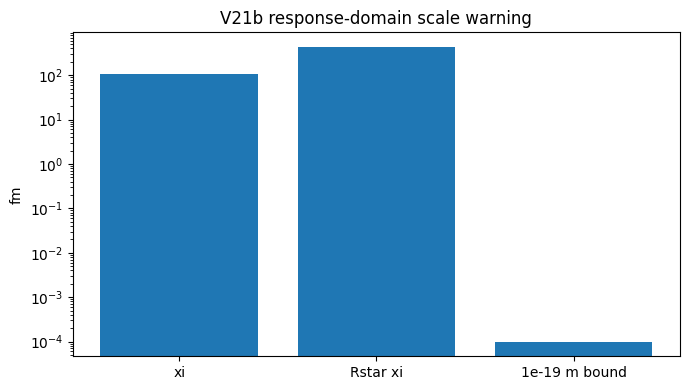

In [8]:
# =========================================
# CELL 8 — response-domain scale warning
# =========================================

# Convert the recovered energy unit to a coherence length.
# As before, R* xi is NOT interpreted as an electromagnetic charge radius.

xi_action_m = hbar*c/(E0_action_MeV * 1e3 * J_per_keV)
xi_action_fm = xi_action_m / 1e-15
tau_action_s = xi_action_m / c
literal_Rxi_m = R_star * xi_action_m
literal_Rxi_fm = literal_Rxi_m / 1e-15
radius_bound_m = 1e-19

radius_warning = {
    "xi_action_m": xi_action_m,
    "xi_action_fm": xi_action_fm,
    "tau_action_s": tau_action_s,
    "literal_Rstar_xi_m": literal_Rxi_m,
    "literal_Rstar_xi_fm": literal_Rxi_fm,
    "ratio_to_1e_minus_19_m_bound": literal_Rxi_m / radius_bound_m,
    "literal_radius_problem_if_taken_as_charge_radius": bool(literal_Rxi_m > radius_bound_m),
    "interpretation": "R*xi is a response-domain coherence scale, not an electromagnetic charge radius."
}
with open(OUT / "literal_response_domain_scale_warning_v21b.json", "w") as f:
    json.dump(radius_warning, f, indent=2)

print(json.dumps(radius_warning, indent=2))

plt.figure(figsize=(7,4))
plt.bar(["xi", "Rstar xi", "1e-19 m bound"], [xi_action_fm, literal_Rxi_fm, radius_bound_m/1e-15])
plt.yscale("log")
plt.ylabel("fm")
plt.title("V21b response-domain scale warning")
plt.tight_layout()
plt.savefig(OUT / "fig_v21b_response_domain_scale_warning.png", dpi=200)
plt.show()

In [9]:
# =====================================
# CELL 9 — no-cheat and final verdict
# =====================================

no_cheat = {
    "single_action_recovery_used": True,
    "electron_mass_used_as_target_only": True,
    "electron_mass_inserted_into_action": False,
    "E0_set_equal_to_511keV": False,
    "p_solved_from_electron_mass": False,
    "xi_solved_from_electron_mass": False,
    "tau_solved_from_electron_mass": False,
    "scale_fit_performed_against_electron_mass": False,
    "q_branch_derived_from_action_scan": q_branch_pass,
    "closure_sequence_derived_from_hessian_degeneracy": closure_pass,
    "alpha_beta_algebra_recovered": bool(max_alpha_beta_error == 0.0),
    "V17_minimum_recovered_by_single_action": abs(recovery_summary["R_error_vs_v17"]) < 1e-3,
    "V17_energy_recovered_by_single_action": abs(recovery_summary["E_error_vs_v17"]) < 1e-4,
    "V17_curvature_recovered_by_single_action": abs(recovery_summary["curvature_error_vs_v17"]) < 1e-4,
    "stiffness_action_rule_generated_after_action_recovery": True,
    "electron_mass_derivation_claimed": False,
    "full_QED_derivation_claimed": False,
    "literal_radius_warning_tracked": True,
    "V22_required_for_field_theory_and_radiative_corrections": True
}
with open(OUT / "no_cheat_audit_v21b.json", "w") as f:
    json.dump(no_cheat, f, indent=2)

criteria = [
    ("q=-1 branch recovered", float(best_branch["q"]), q_branch_pass),
    ("closure sequence 2,8,18,32 recovered", len(closure_sequence), closure_pass),
    ("alpha/beta response algebra recovered", max_alpha_beta_error, max_alpha_beta_error == 0.0),
    ("single action finite minimum exists", E_min_refined, E_min_refined < 0 and not recovery_summary["boundary_minimum"]),
    ("action R matches V17", recovery_summary["R_error_vs_v17"], abs(recovery_summary["R_error_vs_v17"]) < 1e-3),
    ("action E matches V17", recovery_summary["E_error_vs_v17"], abs(recovery_summary["E_error_vs_v17"]) < 1e-4),
    ("action curvature matches V17", recovery_summary["curvature_error_vs_v17"], abs(recovery_summary["curvature_error_vs_v17"]) < 1e-4),
    ("p generated before target comparison", p_action, True),
    ("mass scale within 1 percent", abs_percent_error, abs_percent_error < 1.0),
    ("mass scale within 5 percent", abs_percent_error, abs_percent_error < 5.0),
    ("no E0=511keV shortcut", 0.0, not no_cheat["E0_set_equal_to_511keV"]),
    ("p not solved from electron mass", 0.0, not no_cheat["p_solved_from_electron_mass"]),
    ("xi not solved from electron mass", 0.0, not no_cheat["xi_solved_from_electron_mass"]),
    ("tau not solved from electron mass", 0.0, not no_cheat["tau_solved_from_electron_mass"]),
    ("no electron-mass fit performed", 0.0, not no_cheat["scale_fit_performed_against_electron_mass"]),
    ("literal response-domain scale warning tracked", 1.0, no_cheat["literal_radius_warning_tracked"]),
    ("full QED derivation not overclaimed", 1.0, not no_cheat["full_QED_derivation_claimed"]),
]
verdict_df = pd.DataFrame([{"criterion": c, "value": v, "pass": bool(p)} for c,v,p in criteria])
verdict_df.to_csv(OUT / "final_single_action_recovery_v21b_verdict.csv", index=False)
display(verdict_df)

n_pass = int(verdict_df["pass"].sum())
n_criteria = len(verdict_df)

if abs_percent_error < 1.0 and all(verdict_df["pass"]):
    label = "PASS_STRONG_RECOVERY: V21b recovers the V17 single-action minimum and regenerates the near-electron rest-energy scale without solving from m_e."
elif abs_percent_error < 5.0:
    label = "PASS_RECOVERY: V21b recovers the V17 single-action minimum and lands within 5 percent of the electron-like rest-energy scale."
else:
    label = "FAIL_PRODUCTIVE: V21b recovers structure but not the electron-like rest-energy scale."

run_summary = {
    "final_label": label,
    "n_pass": n_pass,
    "n_criteria": n_criteria,
    "q_action": float(best_branch["q"]),
    "closure_sequence": closure_sequence,
    "max_alpha_beta_error": max_alpha_beta_error,
    "R_star_recovered": recovery_summary["R_star_action_recovered"],
    "E_star_recovered": recovery_summary["E_star_action_recovered"],
    "curvature_recovered": recovery_summary["curvature_action_recovered"],
    "p_action": p_action,
    "E0_action_MeV": E0_action_MeV,
    "Ephys_action_keV": Ephys_action_keV,
    "electron_rest_energy_target_keV": electron_target_keV,
    "ratio_to_electron_target": ratio_to_target,
    "abs_percent_error": abs_percent_error,
    "electron_mass_derivation_claimed": False,
    "full_QED_derivation_claimed": False,
    "notes": "V21b is a recovery notebook. It restores the V17 rest-energy minimum as a single action and then reruns the stiffness/action mass-scale audit. It does not claim a full QED derivation."
}
with open(OUT / "run_summary_v21b.json", "w") as f:
    json.dump(run_summary, f, indent=2)

print("Final label:", label)
print(json.dumps(run_summary, indent=2))

manifest = pd.DataFrame({"file": sorted([p.name for p in OUT.iterdir() if p.is_file()])})
manifest.to_csv(OUT / "manifest_v21b.csv", index=False)
display(manifest)

zip_name = "ecsm_electron_single_action_recovery_v21b_out.zip"
with zipfile.ZipFile(zip_name, "w", zipfile.ZIP_DEFLATED) as z:
    for p in OUT.iterdir():
        if p.is_file():
            z.write(p, arcname=p.name)
print("Zipped output:", zip_name)
print("Notebook complete.")

,criterion,value,pass
0,q=-1 branch recovered,-1.000000e+00,True
1,"closure sequence 2,8,18,32 recovered",4.000000e+00,True
2,alpha/beta response algebra recovered,0.000000e+00,True
3,single action finite minimum exists,-2.763714e-01,True
4,action R matches V17,-1.103021e-08,True
5,action E matches V17,-2.046191e-11,True
6,action curvature matches V17,1.111034e-06,True
7,p generated before target comparison,1.021003e+01,True
8,mass scale within 1 percent,6.009652e-01,True
9,mass scale within 5 percent,6.009652e-01,True


Final label: PASS_STRONG_RECOVERY: V21b recovers the V17 single-action minimum and regenerates the near-electron rest-energy scale without solving from m_e.
{
  "final_label": "PASS_STRONG_RECOVERY: V21b recovers the V17 single-action minimum and regenerates the near-electron rest-energy scale without solving from m_e.",
  "n_pass": 17,
  "n_criteria": 17,
  "q_action": -1.0,
  "closure_sequence": [
    2,
    8,
    18,
    32
  ],
  "max_alpha_beta_error": 0.0,
  "R_star_recovered": 4.057953270393597,
  "E_star_recovered": -0.27637139084338974,
  "curvature_recovered": 0.03191359462708962,
  "p_action": 10.210030664542186,
  "E0_action_MeV": 1.860069073152257,
  "Ephys_action_keV": 514.0698767738036,
  "electron_rest_energy_target_keV": 510.9989506917532,
  "ratio_to_electron_target": 1.0060096524227558,
  "abs_percent_error": 0.6009652422755751,
  "electron_mass_derivation_claimed": false,
  "full_QED_derivation_claimed": false,
  "notes": "V21b is a recovery notebook. It restores t

,file
0,action_derived_bipolar_occupation_branches_v21...
1,action_derived_shell_closure_v21b.csv
2,action_hessian_alpha_beta_algebra_tests_v21b.csv
3,chi_epsilon_single_action_recovery_robustness_...
4,fig_v21b_action_derived_bipolar_occupation.png
5,fig_v21b_chi_epsilon_mass_scale_robustness.png
6,fig_v21b_mass_scale_comparison.png
7,fig_v21b_recovered_action_planck_alpha_mass_sc...
8,fig_v21b_response_domain_scale_warning.png
9,fig_v21b_single_action_component_ledger.png


Zipped output: ecsm_electron_single_action_recovery_v21b_out.zip
Notebook complete.
